In [75]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score,roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from skfeature.function.similarity_based import fisher_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import numpy as np

In [76]:
print("Loading dataset ...")
df = pd.read_csv('/Users/irene/Library/CloudStorage/OneDrive-UNIPA/UNIPA/DIDATTICA/ESAMI BD/dataset/spotify.csv')

df

Loading dataset ...


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6QLFNz62dpOgQTloWuUbNh,All Things Must Pass,George Harrison,58,4I4xtHaIFOzhZfp1NIHkY6,All Things Must Pass (Remastered),1970-11-27,I didn’t know perm stood for permanent (wave),3e6gYPyrTbaB8BWgSHCt5j,rock,...,9,-8.278,1,0.0290,0.468000,0.001340,0.1110,0.441,122.676,226867
1,5JkKam7azyOKIW8Yy0u9fQ,Told You Once,Frank Brinelle,42,3wcloL3xLM9wKYrHG2K7y4,Told You Once,2018-05-13,Tropical Vibes,37i9dQZF1DX6RA5ZrA5a23,latin,...,8,-9.480,1,0.0942,0.062500,0.899000,0.0922,0.384,199.886,194437
2,0eOOTL9t2P448umBMf8vcS,Wasabi Terraces,Testiculo y Uno,56,5ryOyyt5nd8JUDtJreLgNv,Wasabi Terraces,2019-12-18,Jazz Vibes,37i9dQZF1DX0SM0LYsmbMT,rap,...,2,-11.114,1,0.0519,0.177000,0.609000,0.7060,0.583,87.213,188053
3,1yLFnEUfKDGCDeXcp1nIem,Magpakailanman,Rocksteddy,50,2Mng4RzoMnhpQcVo7TFkNy,Tsubtsatagilidakeyn,2005-05-11,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,rock,...,9,-6.988,1,0.0259,0.062100,0.000000,0.1570,0.332,105.042,326120
4,0zEnD8K1PZROX1Zsr7QZeq,Апокалипсис,Vitya AK,0,2qn8HTfrtqcGnrxKmGHa1R,Жирный,2012-06-01,RUSSIAN Gangster Rap,0Jw0HckkxCfIrOvpN081eV,rap,...,9,-6.502,0,0.3720,0.721000,0.000000,0.1120,0.708,169.980,259843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,40lcA4lHEMDvwoDMcwd1Xb,MoneyMoney,Tight Rhymes,41,1o9vkmWlF2YUoQuG0OosxB,MoneyMoney,2019-11-22,Great Pops,5SO7xYih5w8X5FEpKvU7Rt,latin,...,11,-5.118,1,0.3110,0.191000,0.052900,0.1100,0.569,86.037,187548
7936,0eaSdnDwPCoXMwPMwko4Ne,De Repente,Soraya,54,0mHG8x3lDk1RaGfHeNQGDV,Esenciales,2003-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,8,-11.527,1,0.0348,0.762000,0.002450,0.3370,0.805,118.033,247467
7937,2LyrufB6lwhwHq0mT3Dihs,No Dices Mas,Mœnia,2,1f34JO0Wtr9YFa4uXM27Vy,Grandes Exitos,2005-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,1,-6.292,1,0.0282,0.055500,0.000672,0.0735,0.690,127.032,255733
7938,7881kSmOadyJQqKw4J3InC,Tempo,Olszakumpel,56,2fDZUFbfio7feaIvhNIlTw,Tempo,2019-11-22,Generacja Hip Hop,37i9dQZF1DWXJnyndhASBe,rap,...,8,-3.846,1,0.2040,0.251000,0.000000,0.3030,0.566,149.923,205055


['rock' 'latin' 'rap' 'edm' 'r&b' 'pop']


<Axes: xlabel='playlist_genre'>

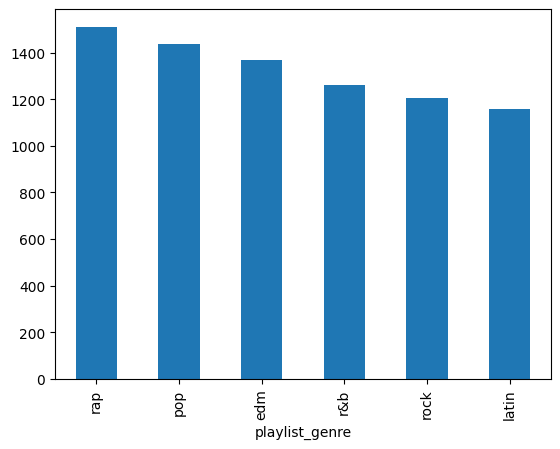

In [77]:
# playlist_genre can be considered as our classification label
print(df.playlist_genre.unique())
# plot labels distribution
df['playlist_genre'].value_counts().plot(kind='bar')

In [78]:
# Multi-class classification: keep ALL genres
SEED = 17

# Shuffle the full dataset
df_multi = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Dataset shape:', df_multi.shape)
print(df_multi['playlist_genre'].value_counts())

Dataset shape: (7940, 23)
playlist_genre
rap      1512
pop      1436
edm      1367
r&b      1261
rock     1206
latin    1158
Name: count, dtype: int64


In [79]:
# Encode all genre labels
df_labels = df_multi['playlist_genre']

le = LabelEncoder()
y = le.fit_transform(df_labels)

print('Classes:', le.classes_)
print('Encoded as:', list(range(len(le.classes_))))
y

Classes: ['edm' 'latin' 'pop' 'r&b' 'rap' 'rock']
Encoded as: [0, 1, 2, 3, 4, 5]


array([4, 1, 3, ..., 5, 1, 3], shape=(7940,))

In [80]:
# Select only numerical features
df_features = df_multi[['danceability', 'energy', 'key', 'loudness', 'mode',
                         'speechiness', 'acousticness', 'instrumentalness',
                         'liveness', 'valence', 'tempo', 'duration_ms']].copy()

df_features

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.527,0.683,8,-5.023,1,0.0350,0.40700,0.000002,0.1010,0.1140,92.986,196000
1,0.685,0.912,10,-3.411,1,0.0687,0.05380,0.000000,0.3920,0.5110,99.957,235720
2,0.250,0.215,8,-13.676,0,0.0370,0.63200,0.071700,0.4010,0.0746,174.824,195987
3,0.738,0.934,6,-3.729,0,0.1200,0.00176,0.000000,0.0473,0.5470,104.970,201160
4,0.293,0.460,7,-6.992,1,0.0335,0.14000,0.000000,0.0779,0.1910,97.635,480547
...,...,...,...,...,...,...,...,...,...,...,...,...
7935,0.618,0.211,9,-16.410,1,0.2080,0.87600,0.849000,0.0887,0.1420,83.982,85714
7936,0.345,0.327,9,-14.856,0,0.0610,0.93800,0.000378,0.1360,0.7220,163.377,270361
7937,0.566,0.521,7,-11.824,1,0.0321,0.51400,0.000288,0.1160,0.4680,129.167,299827
7938,0.839,0.913,3,-5.329,1,0.1660,0.26400,0.000000,0.0559,0.9560,115.585,243280


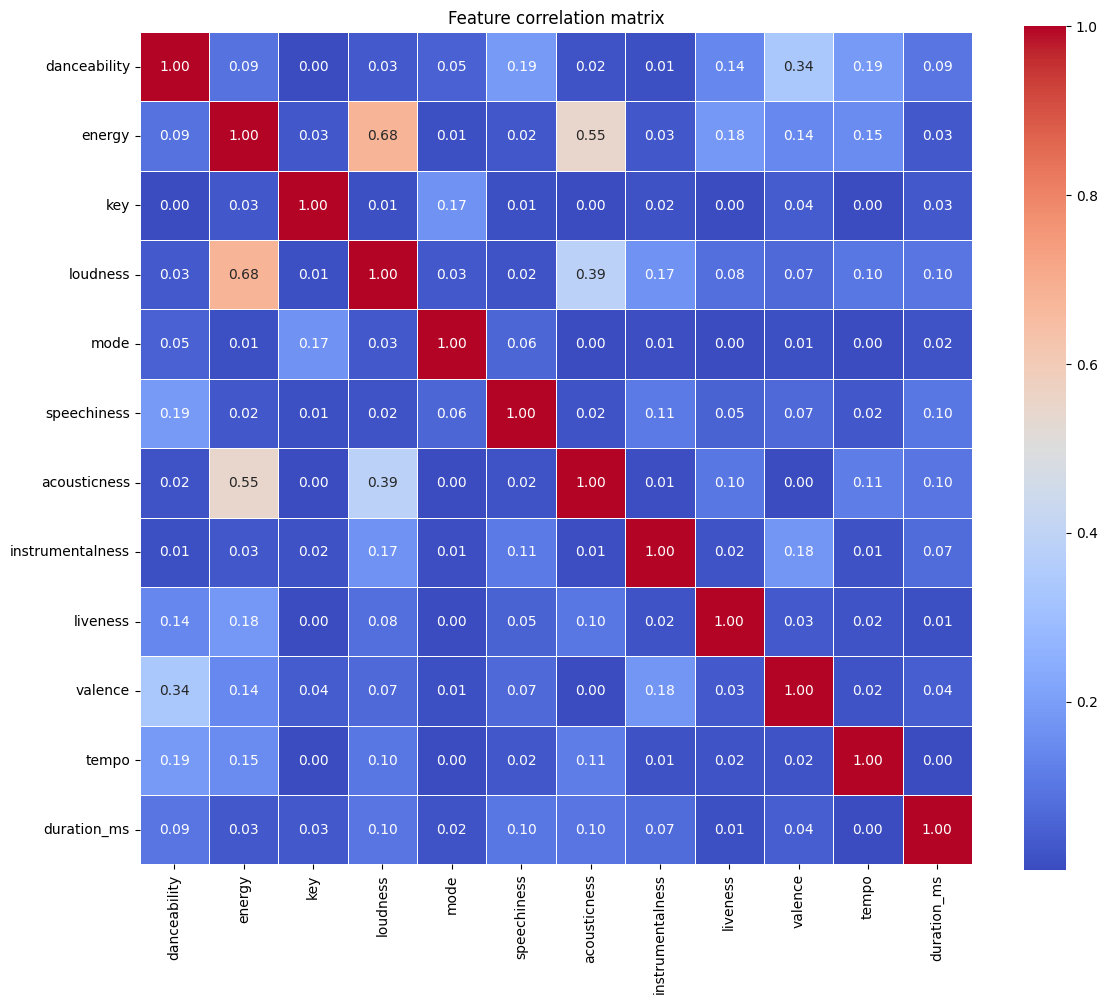

In [81]:
# check for multicollinear features
corr_matrix = df_features.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [82]:
# From the graphical correlation matrix -> High correlation between loudness and energy -> create a new feature as their sum (or any other linear combination to remove the multicollinearity)
# We can also consider a threshold over which the two features are fused together

df_features['loud_ener_acust'] = df_features['loudness'] + df_features['energy'] + df_features['acousticness']

df_features = df_features.drop(columns=['loudness', 'acousticness', 'energy'])

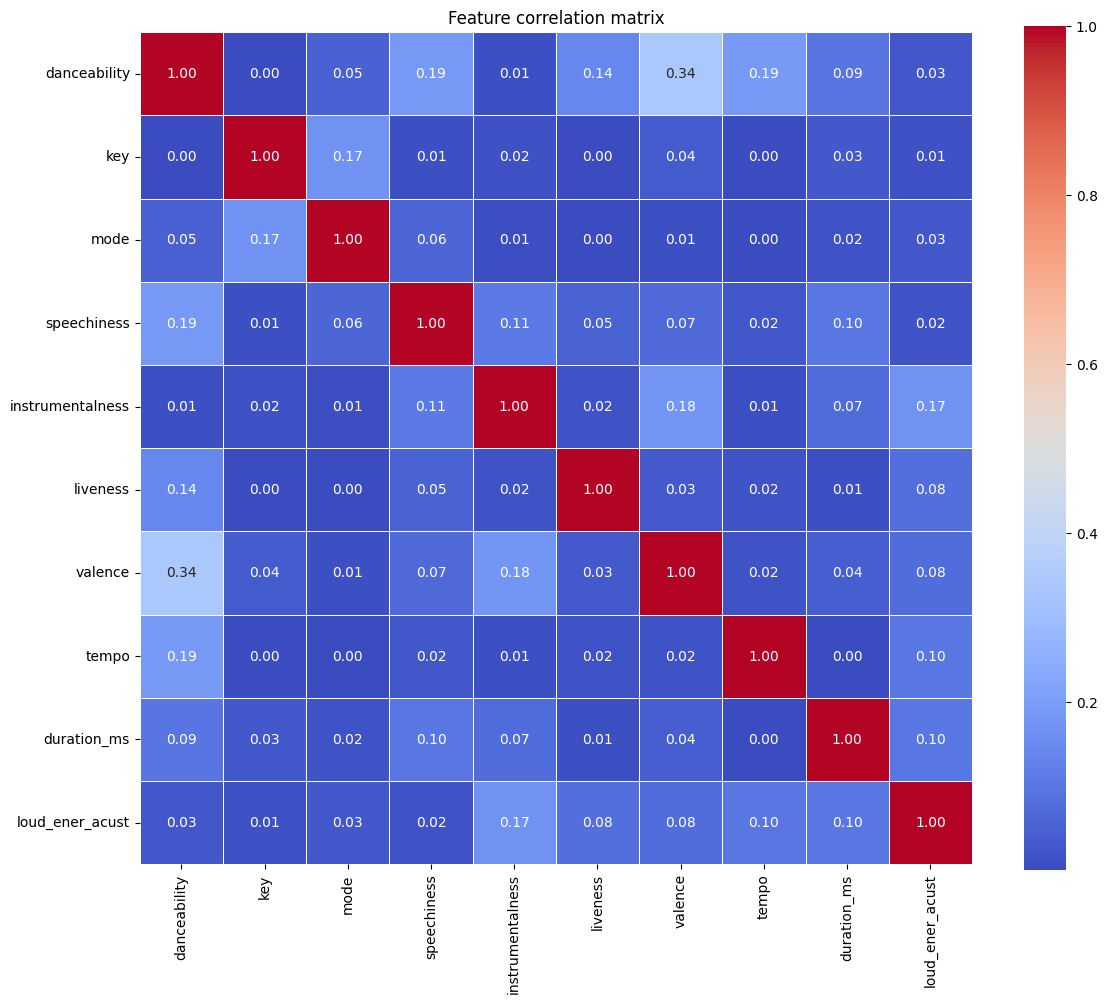

In [83]:
# check for correlation matrix after features removal
corr_matrix = df_features.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [84]:
# filer-based feature selection w/ fisher_score

K_BEST = 8    # number of features to keep

selector = SelectKBest(score_func=fisher_score.fisher_score, k=K_BEST)
df_filter = selector.fit_transform(df_features, y)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = df_features.columns[selected_mask].tolist()
print(f'Top {K_BEST} features selected:', selected_features)

print(df_filter.shape)
print(df_filter[0])

Top 8 features selected: ['danceability', 'key', 'mode', 'instrumentalness', 'valence', 'tempo', 'duration_ms', 'loud_ener_acust']
(7940, 8)
[ 5.2700e-01  8.0000e+00  1.0000e+00  1.9200e-06  1.1400e-01  9.2986e+01
  1.9600e+05 -3.9330e+00]


In [85]:
# Build final feature DataFrame from selected columns
X = pd.DataFrame(df_filter, columns=selected_features)
print('Final feature matrix shape:', X.shape)
X.head(3)

Final feature matrix shape: (7940, 8)


,danceability,key,mode,instrumentalness,valence,tempo,duration_ms,loud_ener_acust
0,0.527,8.0,1.0,0.000002,0.1140,92.986,196000.0,-3.9330
1,0.685,10.0,1.0,0.000000,0.5110,99.957,235720.0,-2.4452
2,0.250,8.0,0.0,0.071700,0.0746,174.824,195987.0,-12.8290


In [86]:
# perform a train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,                         # Takes 20% of the data
    stratify=y,   # Ensures 'label' proportions are kept
    random_state=SEED,                      # For reproducibility
)

In [87]:
# perform standardization over the numerical features of the dataset
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on training data only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

In [88]:
# Decision Tree — natively supports multi-class classification
dt_classifier = DecisionTreeClassifier(random_state=SEED)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

# Set up the Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_classifier, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',
)

grid_search.fit(X_train, y_train)

# Best parameter combination found
print(f"Best Parameters: {grid_search.best_params_}")

# Best cross-validation score achieved during grid search
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 10}
Best Cross-Validation Score: 0.4018
Test Set Accuracy: 0.4125


In [89]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

         edm       0.63      0.64      0.64       273
       latin       0.33      0.24      0.28       232
         pop       0.27      0.30      0.29       287
         r&b       0.32      0.30      0.31       252
         rap       0.44      0.45      0.45       303
        rock       0.45      0.51      0.48       241

    accuracy                           0.41      1588
   macro avg       0.41      0.41      0.41      1588
weighted avg       0.41      0.41      0.41      1588



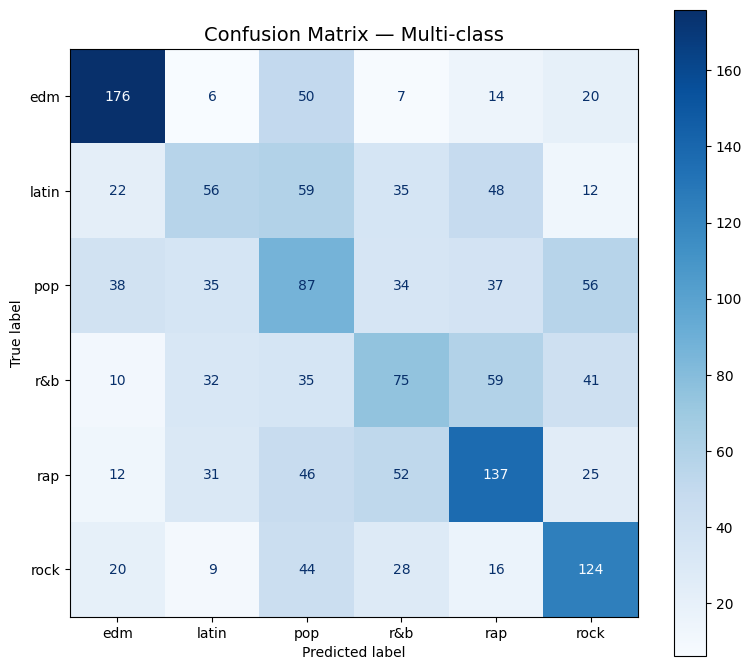

In [90]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix — Multi-class', fontsize=14)
plt.tight_layout()
plt.show()

In [91]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
print(y_onehot_test.shape)  # (n_samples, n_classes)
print(y_onehot_test[0])     # label one-hot encoding

(1588, 6)
[0 0 0 0 1 0]


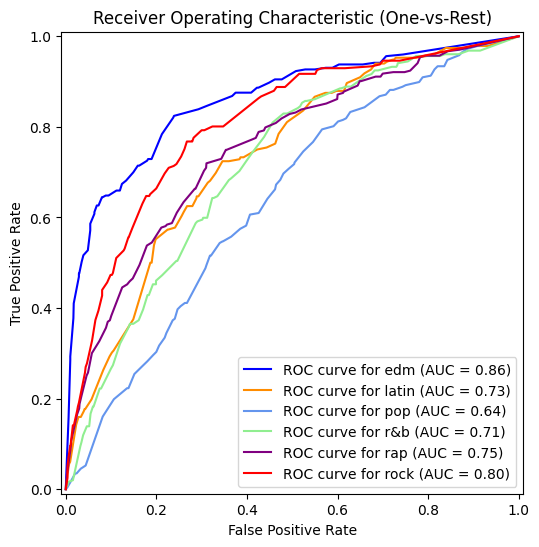

In [95]:
# Calculate probabilities
y_score = best_model.predict_proba(X_test)
n_classes = len(le.classes_)

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))

colors = ['blue', 'darkorange', 'cornflowerblue', 'lightgreen', 'purple', 'red']
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {le.classes_[class_id]}",
        curve_kwargs=dict(color=color),
        ax=ax,
    )

ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", 
       title="Receiver Operating Characteristic (One-vs-Rest)")
plt.show()